# Go2 Joystick Policy with APG Training Notebook

In [24]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [25]:
import os

xla_flags = os.environ.get("XLA_FLAGS", "")
xla_flags += " --xla_gpu_triton_gemm_any=True"
os.environ["XLA_FLAGS"] = xla_flags
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
os.environ["MUJOCO_GL"] = "egl"
# os.environ['MUJOCO_GL'] = 'osmesa'
os.environ["CUDA_VISIBLE_DEVICES"] = "3"

In [26]:
import functools
import json
from datetime import datetime

# --- JAX Configuration (MUST be done before other JAX imports) ---
import jax
from jax import config

# Use 64-bit precision (Must be set before backend initialization)
config.update("jax_enable_x64", True)

# Other JAX configs
config.update("jax_debug_nans", False)
config.update("jax_default_matmul_precision", "high")

# Compilation cache configuration
cache_path = "/data/jit_cache"
if not os.path.exists(cache_path):
    os.makedirs(cache_path)
    print(f"Created JAX compilation cache directory at {cache_path}")

config.update("jax_compilation_cache_dir", cache_path)
config.update("jax_persistent_cache_min_entry_size_bytes", -1)
config.update("jax_persistent_cache_min_compile_time_secs", 1)
# -----------------------------------------------------------------

# Now import libraries that depend on JAX
import jax.numpy as jp
import matplotlib.pyplot as plt
import mediapy as media
import mujoco
import numpy as np
import wandb

from brax.training.agents.ppo import networks as ppo_networks
from brax.training.agents.ppo import train as ppo
from apg_alg.algorithm import apg
from apg_alg.networks import apg_networks

from etils import epath
from flax.training import orbax_utils
from IPython.display import clear_output, display
from orbax import checkpoint as ocp

from mujoco_playground import locomotion, wrapper
from mujoco_playground.config import locomotion_params

print("JAX configured. x64 enabled:", config.read("jax_enable_x64"))

JAX configured. x64 enabled: True


In [27]:
# env_name = "Go2Joystick"
env_name = "Go2SmoothJoystick"
env_cfg = locomotion.get_default_config(env_name)
randomizer = locomotion.get_domain_randomizer(env_name)
apg_params = locomotion_params.brax_apg_config(env_name)

In [28]:
# env_cfg.episode_length = 500  # Shorten episode length so we don't go out of boudns of the hfield.
# env_cfg.pert_config.velocity_kick = [3.0, 6.0]
# env_cfg.pert_config.kick_wait_times = [5.0, 15.0]
# env_cfg.command_config.a = [1.5, 0.8, 2*jp.pi]
# env_cfg.noise_config.level = 0.0
# env_cfg.sim_dt=0.02

In [29]:
# apg_params["policy_updates"] = 1500
# apg_params["deterministic_eval"] = False
# apg_params["num_envs"] = 64
# apg_params["num_eval_envs"] = 64
apg_params["horizon_length"] = 64
# apg_params["normalize_observations"] = True

In [30]:
from pprint import pprint

pprint(apg_params)

action_repeat: 1
deterministic_eval: false
episode_length: 240
horizon_length: 64
learning_rate: 0.0001
max_gradient_norm: 1000.0
network_factory:
  hidden_layer_sizes: !!python/tuple
  - 512
  - 256
  - 128
  policy_obs_key: state
normalize_observations: true
num_envs: 64
num_eval_envs: 64
num_evals: 11
policy_updates: 499
use_float64: true



In [31]:
pprint(env_cfg)

Kd: 0.5
Kp: 35.0
action_repeat: 1
action_scale: 0.5
command_config:
  a:
  - 1.5
  - 0.8
  - 1.2
  b:
  - 0.9
  - 0.25
  - 0.5
ctrl_dt: 0.02
env:
  impratio: 100
episode_length: 1000
history_len: 1
impl: jax
nconmax: 32768
njmax: 40
noise_config:
  level: 1.0
  scales:
    gravity: 0.05
    gyro: 0.2
    joint_pos: 0.03
    joint_vel: 1.5
    linvel: 0.1
pert_config:
  enable: false
  kick_durations:
  - 0.05
  - 0.2
  kick_wait_times:
  - 1.0
  - 3.0
  velocity_kick:
  - 0.0
  - 3.0
reward_config:
  max_foot_height: 0.1
  scales:
    action_rate: -0.01
    ang_vel_xy: -0.05
    dof_pos_limits: -1.0
    energy: -0.001
    feet_air_time: 0.1
    feet_clearance: -2.0
    feet_height: -0.2
    feet_slip: -0.1
    lin_vel_z: -0.5
    orientation: -5.0
    pose: 0.5
    stand_still: -1.0
    termination: -1.0
    torques: -0.0002
    tracking_ang_vel: 0.5
    tracking_lin_vel: 1.0
  tracking_sigma: 0.25
sim_dt: 0.004
soft_joint_pos_limit_factor: 0.95



In [32]:
# Setup wandb logging.
USE_WANDB = True

if USE_WANDB:
  wandb.init(project="mjplayground-apg-go2-joystick", config=env_cfg)
  wandb.config.update({
      "env_name": env_name,
  })

In [33]:
SUFFIX = None
FINETUNE_PATH = None

# Generate unique experiment name.
now = datetime.now()
timestamp = now.strftime("%Y%m%d-%H%M%S")
exp_name = f"{env_name}-{timestamp}-apg"
if SUFFIX is not None:
  exp_name += f"-{SUFFIX}"
print(f"Experiment name: {exp_name}")

# Possibly restore from the latest checkpoint.
if FINETUNE_PATH is not None:
  FINETUNE_PATH = epath.Path(FINETUNE_PATH)
  latest_ckpts = list(FINETUNE_PATH.glob("*"))
  latest_ckpts = [ckpt for ckpt in latest_ckpts if ckpt.is_dir()]
  latest_ckpts.sort(key=lambda x: int(x.name))
  latest_ckpt = latest_ckpts[-1]
  restore_checkpoint_path = latest_ckpt
  print(f"Restoring from: {restore_checkpoint_path}")
else:
  restore_checkpoint_path = None

Experiment name: Go2SmoothJoystick-20260123-132949-apg


In [34]:
ckpt_path = epath.Path("checkpoints").resolve() / exp_name
ckpt_path.mkdir(parents=True, exist_ok=True)
print(f"Checkpoint path: {ckpt_path}")

with open(ckpt_path / "config.json", "w") as fp:
  json.dump(env_cfg.to_dict(), fp, indent=4)

Checkpoint path: /data/mujoco_playground/mujoco_playground/experimental/learning/checkpoints/Go2SmoothJoystick-20260123-132949-apg


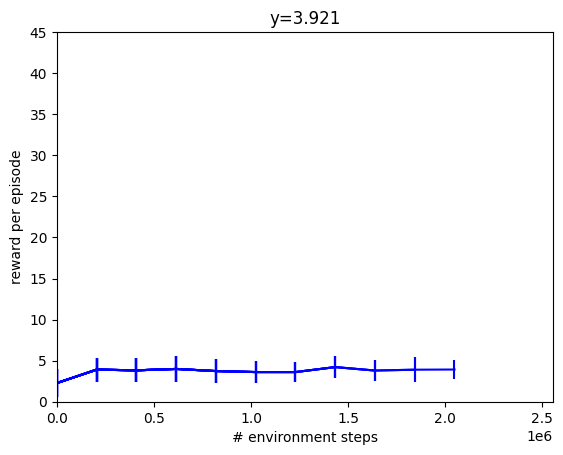

time to jit: 0:03:15.392057
time to train: 0:19:34.079965


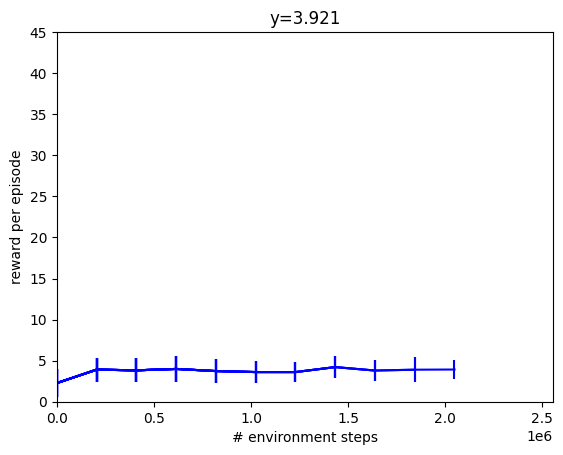

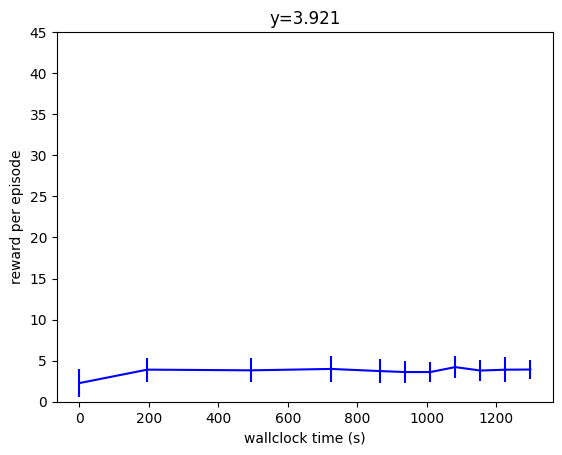

eval/avg_episode_length,▁██████████
eval/episode_reward,▁▇▇▇▆▆▆█▆▇▇
eval/episode_reward/action_rate,▁▂▅▇▇▇▇████
eval/episode_reward/action_rate_std,▅█▃▁▁▁▁▂▁▁▁
eval/episode_reward/ang_vel_xy,▁▆▇████████
eval/episode_reward/ang_vel_xy_std,█▂▁▁▁▁▁▁▁▁▁
eval/episode_reward/dof_pos_limits,▁▁▁▁▁▁▁▁▁▁▁
eval/episode_reward/dof_pos_limits_std,▁▁▁▁▁▁▁▁▁▁▁
eval/episode_reward/energy,▁▄▆▇▇▇▇████
eval/episode_reward/energy_std,█▅▃▂▂▂▁▁▁▁▁
+35,...


W&B Run finished.


In [35]:
x_data, y_data, y_dataerr = [], [], []
times = [datetime.now()]

updates_per_epoch = round(apg_params["policy_updates"] / max(apg_params["num_evals"] - 1, 1))
scale_it = updates_per_epoch * apg_params["horizon_length"] * apg_params["num_envs"]

def progress(num_steps, metrics):
  # Log to wandb.
  if USE_WANDB:
    wandb.log(metrics, step=num_steps * scale_it)

  # Plot.
  clear_output(wait=True)
  times.append(datetime.now())
  x_data.append(num_steps * scale_it)
  y_data.append(metrics["eval/episode_reward"])
  y_dataerr.append(metrics["eval/episode_reward_std"])

  plt.xlim([0, apg_params.policy_updates * apg_params.horizon_length * apg_params.num_envs * 1.25])
  plt.ylim([0, 45])
  plt.xlabel("# environment steps")
  plt.ylabel("reward per episode")
  plt.title(f"y={y_data[-1]:.3f}")
  plt.errorbar(x_data, y_data, yerr=y_dataerr, color="blue")

  display(plt.gcf())


def policy_params_fn(current_step, make_policy, params):
  del make_policy  # Unused.
  orbax_checkpointer = ocp.PyTreeCheckpointer()
  save_args = orbax_utils.save_args_from_target(params)
  path = ckpt_path / f"{current_step}"
  orbax_checkpointer.save(path, params, force=True, save_args=save_args)

training_params = dict(apg_params)
del training_params["network_factory"]

train_fn = functools.partial(
  apg.train,
  **training_params,
  network_factory=functools.partial(
      apg_networks.make_apg_networks,
      **apg_params.network_factory
  ),
  # restore_checkpoint_path=restore_checkpoint_path,
  progress_fn=progress,
  wrap_env_fn=wrapper.wrap_for_brax_training,
  # policy_params_fn=policy_params_fn,
  randomization_fn=randomizer,
)

env = locomotion.load(env_name, config=env_cfg)
eval_env = locomotion.load(env_name, config=env_cfg)
make_inference_fn, params, _ = train_fn(environment=env, eval_env=eval_env)
if len(times) > 1:
  print(f"time to jit: {times[1] - times[0]}")
  print(f"time to train: {times[-1] - times[1]}")

# Make a final plot of reward and success vs WALLCLOCK time.
plt.figure()
plt.ylim([0, 45])
plt.xlabel("wallclock time (s)")
plt.ylabel("reward per episode")
plt.title(f"y={y_data[-1]:.3f}")
plt.errorbar(
    [(t - times[0]).total_seconds() for t in times[:-1]],
    y_data,
    yerr=y_dataerr,
    color="blue",
)
plt.show()

if USE_WANDB:
    wandb.finish()
    print("W&B Run finished.")

In [36]:
inference_fn = make_inference_fn(params, deterministic=True)
jit_inference_fn = jax.jit(inference_fn)

In [37]:
import pickle
# Save normalizer and policy params to the checkpoint dir.
normalizer_params, policy_params = params
with open(ckpt_path / "params.pkl", "wb") as f:
  data = {
    "normalizer_params": normalizer_params,
    "policy_params": policy_params
  }
  pickle.dump(data, f)

In [38]:
from mujoco_playground._src.gait import draw_joystick_command

# Enable perturbation in the eval env.
env_cfg = locomotion.get_default_config(env_name)
# env_cfg.episode_length = 500  # Shorten episode length so we don't go out of boudns of the hfield.
env_cfg.pert_config.enable = True
env_cfg.pert_config.velocity_kick = [3.0, 6.0]
env_cfg.pert_config.kick_wait_times = [5.0, 15.0]
env_cfg.command_config.a = [1.5, 0.8, 2*jp.pi]
eval_env = locomotion.load(env_name, config=env_cfg)

jit_reset = jax.jit(eval_env.reset)
jit_step = jax.jit(eval_env.step)

Iterations: 1
Tolerance: 1e-08
LS Iterations: 5


In [39]:
velocity_kick_range = [0.0, 0.0]  # Disable velocity kick.
kick_duration_range = [0.05, 0.2]


def sample_pert(rng):
  rng, key1, key2 = jax.random.split(rng, 3)
  pert_mag = jax.random.uniform(
      key1, minval=velocity_kick_range[0], maxval=velocity_kick_range[1]
  )
  duration_seconds = jax.random.uniform(
      key2, minval=kick_duration_range[0], maxval=kick_duration_range[1]
  )
  duration_steps = jp.round(duration_seconds / eval_env.dt).astype(jp.int32)
  state.info["pert_mag"] = pert_mag
  state.info["pert_duration"] = duration_steps
  state.info["pert_duration_seconds"] = duration_seconds
  return rng


rng = jax.random.PRNGKey(0)
rollout = []
modify_scene_fns = []

swing_peak = []
rewards = []
linvel = []
angvel = []
track = []
foot_vel = []
rews = []
contact = []

x = 1.0
y = 0.0
yaw = 0.0
command = jp.array([x, y, yaw])

state = jit_reset(rng)
if state.info["steps_since_last_pert"] < state.info["steps_until_next_pert"]:
  rng = sample_pert(rng)
state.info["command"] = command
for i in range(env_cfg.episode_length):
  if state.info["steps_since_last_pert"] < state.info["steps_until_next_pert"]:
    rng = sample_pert(rng)
  act_rng, rng = jax.random.split(rng)
  ctrl, _ = jit_inference_fn(state.obs, act_rng)
  state = jit_step(state, ctrl)
  state.info["command"] = command
  rews.append(
      {k: v for k, v in state.metrics.items() if k.startswith("reward/")}
  )
  rollout.append(state)
  swing_peak.append(state.info["swing_peak"])
  rewards.append(
      {k[7:]: v for k, v in state.metrics.items() if k.startswith("reward/")}
  )
  linvel.append(env.get_global_linvel(state.data))
  angvel.append(env.get_gyro(state.data))
  track.append(
      env._reward_tracking_lin_vel(
          state.info["command"], env.get_local_linvel(state.data)
      )
  )

  feet_vel = state.data.sensordata[env._foot_linvel_sensor_adr]
  vel_xy = feet_vel[..., :2]
  vel_norm = jp.sqrt(jp.linalg.norm(vel_xy, axis=-1))
  foot_vel.append(vel_norm)

  contact.append(state.info["last_contact"])

  xyz = np.array(state.data.xpos[env._torso_body_id])
  xyz += np.array([0, 0, 0.2])
  x_axis = state.data.xmat[env._torso_body_id, 0]
  yaw = -np.arctan2(x_axis[1], x_axis[0])
  modify_scene_fns.append(
      functools.partial(
          draw_joystick_command,
          cmd=state.info["command"],
          xyz=xyz,
          theta=yaw,
          scl=abs(state.info["command"][0])
          / env_cfg.command_config.a[0],
      )
  )

In [40]:
render_every = 2
fps = 1.0 / eval_env.dt / render_every
traj = rollout[::render_every]
mod_fns = modify_scene_fns[::render_every]

scene_option = mujoco.MjvOption()
scene_option.geomgroup[2] = True
scene_option.geomgroup[3] = False
scene_option.flags[mujoco.mjtVisFlag.mjVIS_CONTACTPOINT] = True
scene_option.flags[mujoco.mjtVisFlag.mjVIS_TRANSPARENT] = False
scene_option.flags[mujoco.mjtVisFlag.mjVIS_PERTFORCE] = True

frames = eval_env._render_trajectory(
    traj,  # 传入 List[State]
    render_every=1,  # <--- 关键！设为 1，因为 traj 已经是切过的了
    camera="track",
    scene_option=scene_option,  # 传入选项
    modify_scene_fns=mod_fns,   # 传入修改函数
    width=640,
    height=480,
)

media.show_video(frames, fps=fps, loop=False)

This browser does not support the video tag.


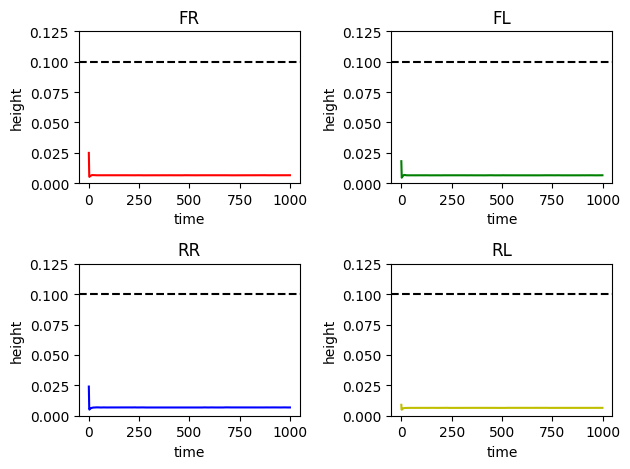

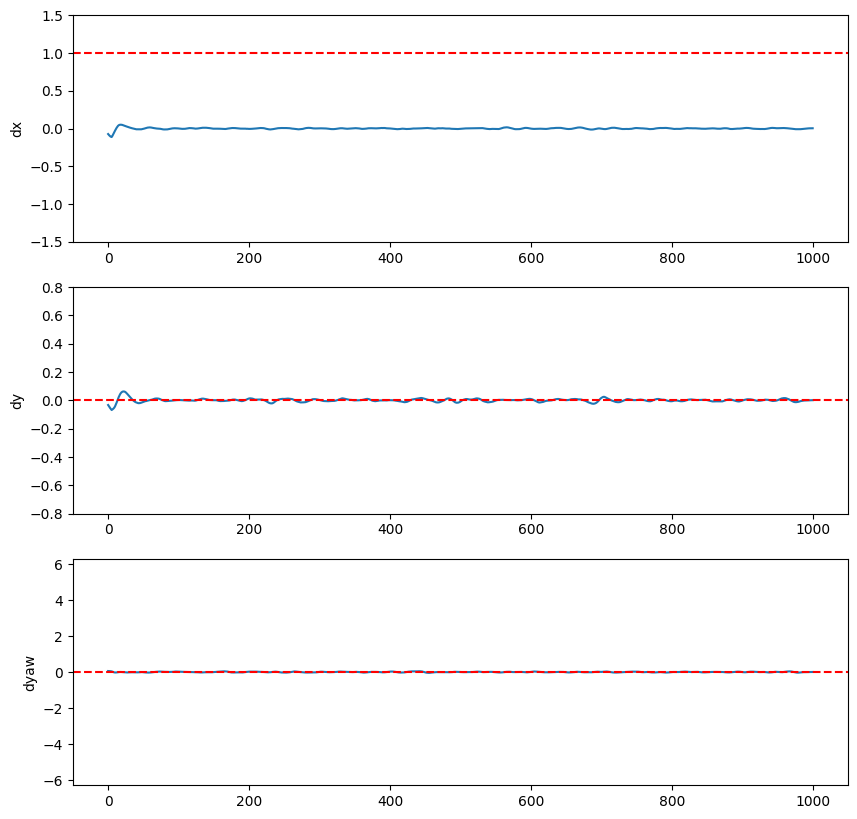

In [41]:
# Plot each foot in a 2x2 grid.
swing_peak = jp.array(swing_peak)
names = ["FR", "FL", "RR", "RL"]
colors = ["r", "g", "b", "y"]
fig, axs = plt.subplots(2, 2)
for i, ax in enumerate(axs.flat):
  ax.plot(swing_peak[:, i], color=colors[i])
  ax.set_ylim([0, env_cfg.reward_config.max_foot_height * 1.25])
  ax.axhline(env_cfg.reward_config.max_foot_height, color="k", linestyle="--")
  ax.set_title(names[i])
  ax.set_xlabel("time")
  ax.set_ylabel("height")
plt.tight_layout()
plt.show()

linvel_x = jp.array(linvel)[:, 0]
linvel_y = jp.array(linvel)[:, 1]
angvel_yaw = jp.array(angvel)[:, 2]

# Plot whether velocity is within the command range.
linvel_x = jp.convolve(linvel_x, jp.ones(10) / 10, mode="same")
linvel_y = jp.convolve(linvel_y, jp.ones(10) / 10, mode="same")
angvel_yaw = jp.convolve(angvel_yaw, jp.ones(10) / 10, mode="same")

fig, axes = plt.subplots(3, 1, figsize=(10, 10))
axes[0].plot(linvel_x)
axes[1].plot(linvel_y)
axes[2].plot(angvel_yaw)

axes[0].set_ylim(
    -env_cfg.command_config.a[0], env_cfg.command_config.a[0]
)
axes[1].set_ylim(
    -env_cfg.command_config.a[1], env_cfg.command_config.a[1]
)
axes[2].set_ylim(
    -env_cfg.command_config.a[2], env_cfg.command_config.a[2]
)

for i, ax in enumerate(axes):
  ax.axhline(state.info["command"][i], color="red", linestyle="--")

labels = ["dx", "dy", "dyaw"]
for i, ax in enumerate(axes):
  ax.set_ylabel(labels[i])

### Run at increasingly faster speeds

In [42]:
rng = jax.random.PRNGKey(0)
rollout = []
modify_scene_fns = []
swing_peak = []
linvel = []
angvel = []

x = -0.25
command = jp.array([x, 0, 0])
state = jit_reset(rng)
for i in range(1_400):
  # Increase the forward velocity by 0.2 m/s every 200 steps.
  if i % 200 == 0:
    x += 0.25
    print(f"Setting x to {x}")
    command = jp.array([x, 0, 0])
  state.info["command"] = command
  if state.info["steps_since_last_pert"] < state.info["steps_until_next_pert"]:
    rng = sample_pert(rng)
  act_rng, rng = jax.random.split(rng)
  ctrl, _ = jit_inference_fn(state.obs, act_rng)
  state = jit_step(state, ctrl)
  rollout.append(state)
  swing_peak.append(state.info["swing_peak"])
  linvel.append(env.get_global_linvel(state.data))
  angvel.append(env.get_gyro(state.data))
  xyz = np.array(state.data.xpos[env._torso_body_id])
  xyz += np.array([0, 0, 0.2])
  x_axis = state.data.xmat[env._torso_body_id, 0]
  yaw = -np.arctan2(x_axis[1], x_axis[0])
  modify_scene_fns.append(
      functools.partial(
          draw_joystick_command,
          cmd=command,
          xyz=xyz,
          theta=yaw,
          scl=abs(command[0]) / env_cfg.command_config.a[0],
      )
  )

Setting x to 0.0
Setting x to 0.25
Setting x to 0.5
Setting x to 0.75
Setting x to 1.0
Setting x to 1.25
Setting x to 1.5


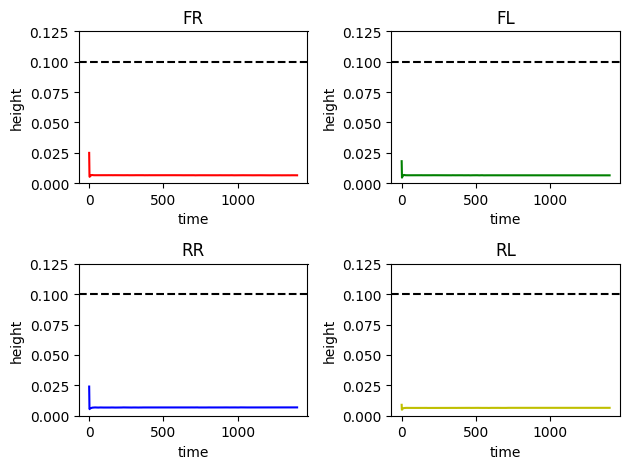

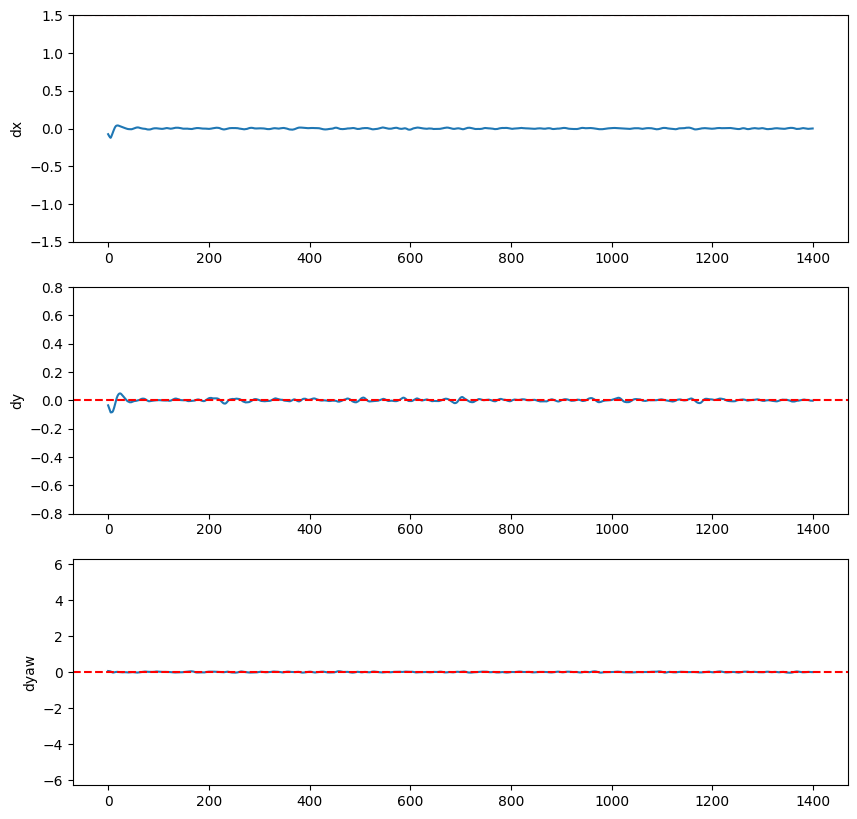

In [43]:
# Plot each foot in a 2x2 grid.
swing_peak = jp.array(swing_peak)
names = ["FR", "FL", "RR", "RL"]
colors = ["r", "g", "b", "y"]
fig, axs = plt.subplots(2, 2)
for i, ax in enumerate(axs.flat):
  ax.plot(swing_peak[:, i], color=colors[i])
  ax.set_ylim([0, env_cfg.reward_config.max_foot_height * 1.25])
  ax.axhline(env_cfg.reward_config.max_foot_height, color="k", linestyle="--")
  ax.set_title(names[i])
  ax.set_xlabel("time")
  ax.set_ylabel("height")
plt.tight_layout()
plt.show()

linvel_x = jp.array(linvel)[:, 0]
linvel_y = jp.array(linvel)[:, 1]
angvel_yaw = jp.array(angvel)[:, 2]

# Plot whether velocity is within the command range.
linvel_x = jp.convolve(linvel_x, jp.ones(10) / 10, mode="same")
linvel_y = jp.convolve(linvel_y, jp.ones(10) / 10, mode="same")
angvel_yaw = jp.convolve(angvel_yaw, jp.ones(10) / 10, mode="same")

fig, axes = plt.subplots(3, 1, figsize=(10, 10))
axes[0].plot(linvel_x)
axes[1].plot(linvel_y)
axes[2].plot(angvel_yaw)

axes[0].set_ylim(
    -env_cfg.command_config.a[0], env_cfg.command_config.a[0]
)
axes[1].set_ylim(
    -env_cfg.command_config.a[1], env_cfg.command_config.a[1]
)
axes[2].set_ylim(
    -env_cfg.command_config.a[2], env_cfg.command_config.a[2]
)

for i, ax in enumerate(axes):
  ax.axhline(state.info["command"][i], color="red", linestyle="--")

labels = ["dx", "dy", "dyaw"]
for i, ax in enumerate(axes):
  ax.set_ylabel(labels[i])

In [44]:
render_every = 2
fps = 1.0 / eval_env.dt / render_every
print(f"fps: {fps}")

traj = rollout[::render_every]
mod_fns = modify_scene_fns[::render_every]
assert len(traj) == len(mod_fns)

scene_option = mujoco.MjvOption()
scene_option.geomgroup[2] = True
scene_option.geomgroup[3] = False
scene_option.flags[mujoco.mjtVisFlag.mjVIS_CONTACTPOINT] = True
scene_option.flags[mujoco.mjtVisFlag.mjVIS_PERTFORCE] = True

frames = eval_env.render(
    traj,
    camera="track",
    height=480,
    width=640,
    modify_scene_fns=mod_fns,
    scene_option=scene_option,
)
media.show_video(frames, fps=fps, loop=False)
# media.write_video(f"{env_name}_faster_commands.mp4", frames, fps=fps, qp=18)

fps: 25.0


100%|██████████| 700/700 [00:08<00:00, 78.49it/s]


This browser does not support the video tag.


### Resist perturbation

In [45]:
rng = jax.random.PRNGKey(67891)
rollout = []
modify_scene_fns = []
n_episodes = 1

x_vel = 0.8
y_vel = 0.0
ang_vel = 0.25
command = jp.array([x_vel, y_vel, ang_vel])

for _ in range(n_episodes):
  state = jit_reset(rng)
  for i in range(1_600):
    if i % 200 == 0:
      x_vel = -x_vel
      y_vel = -y_vel
      ang_vel = -ang_vel
      command = jp.array([x_vel, y_vel, ang_vel])
    state.info["command"] = command
    act_rng, rng = jax.random.split(rng)
    ctrl, _ = jit_inference_fn(state.obs, act_rng)
    state = jit_step(state, ctrl)
    rollout.append(state)
    xyz = np.array(state.data.xpos[env._torso_body_id])
    xyz += np.array([0, 0, 0.2])
    x_axis = state.data.xmat[env._torso_body_id, 0]
    yaw = -np.arctan2(x_axis[1], x_axis[0])
    modify_scene_fns.append(
        functools.partial(
            draw_joystick_command,
            cmd=command,
            xyz=xyz,
            theta=yaw,
            scl=abs(command[0]) / env_cfg.command_config.a[0],
        )
    )

In [46]:
render_every = 1
fps = 1.0 / eval_env.dt / render_every
print(f"fps: {fps}")

traj = rollout[::render_every]
mod_fns = modify_scene_fns[::render_every]
assert len(traj) == len(mod_fns)

scene_option = mujoco.MjvOption()
scene_option.geomgroup[2] = True
scene_option.geomgroup[3] = False
scene_option.flags[mujoco.mjtVisFlag.mjVIS_CONTACTPOINT] = True
scene_option.flags[mujoco.mjtVisFlag.mjVIS_PERTFORCE] = True
## Set to True if you can't see the perturbation force.
scene_option.flags[mujoco.mjtVisFlag.mjVIS_TRANSPARENT] = False

frames = eval_env.render(
    traj,
    camera="track",
    height=480,
    width=640,
    modify_scene_fns=mod_fns,
    scene_option=scene_option,
)
media.show_video(frames, fps=fps, loop=False)
# media.write_video(f"{env_name}_resist_perturbation.mp4", frames, fps=fps, qp=18)

fps: 50.0


100%|██████████| 1600/1600 [00:19<00:00, 82.75it/s]


This browser does not support the video tag.
